
# Итоговая работа: прогнозирование почасового энергопотребления AEP

Этот notebook полностью воспроизводит итоговую работу:

1. подготовка данных и EDA;
2. ≥5 статистических моделей через `statsforecast`;
3. 3 ML-модели через `mlforecast`;
4. 3 DL-модели через `neuralforecast`;
5. backtesting, метрики, интервальные оценки;
6. итоговое сравнение.

**Рекомендуется запускать в Google Colab.**


In [18]:

# Установка библиотек (в Colab выполнить один раз)
!pip -q install statsforecast mlforecast neuralforecast lightgbm xgboost


In [19]:

import os, sys, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.tsa.seasonal import STL

FAST_MODE = True   # False = использовать весь датасет (намного дольше)
H = 24
SEASON = 24
WEEK = 168
N_WINDOWS = 5

DATA_URL = "https://raw.githubusercontent.com/pplonski/datasets-for-start/refs/heads/master/aep-hourly-energy-consumption/AEP_hourly.csv"

os.makedirs("data", exist_ok=True)
os.makedirs("results", exist_ok=True)

def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    err = y_true-y_pred
    return {
        "MAE": np.mean(np.abs(err)),
        "RMSE": np.sqrt(np.mean(err**2)),
        "MAPE": np.mean(np.abs(err)/np.maximum(np.abs(y_true), 1e-8))*100,
        "sMAPE": np.mean(2*np.abs(err)/np.maximum(np.abs(y_true)+np.abs(y_pred),1e-8))*100,
    }



## Задача №1 — загрузка и подготовка данных

Приводим ряд к формату Nixtla: `unique_id`, `ds`, `y`.


In [20]:

raw = pd.read_csv(DATA_URL)
raw["Datetime"] = pd.to_datetime(raw["Datetime"], errors="coerce")
raw = raw.dropna(subset=["Datetime", "AEP_MW"]).sort_values("Datetime")
raw = raw.drop_duplicates("Datetime", keep="last").set_index("Datetime").asfreq("h")

missing_before = int(raw["AEP_MW"].isna().sum())
raw["AEP_MW"] = raw["AEP_MW"].interpolate(limit=3).ffill().bfill()

if FAST_MODE:
    raw = raw.tail(24*365)   # последний год

df = raw.reset_index().rename(columns={"Datetime":"ds", "AEP_MW":"y"})
df["unique_id"] = "AEP"
df = df[["unique_id","ds","y"]]
df.to_csv("data/aep_prepared.csv", index=False)

print("Наблюдений:", len(df))
print("Период:", df.ds.min(), "—", df.ds.max())
print("Пропусков до заполнения:", missing_before)
display(df.head())


Наблюдений: 8760
Период: 2017-08-03 01:00:00 — 2018-08-03 00:00:00
Пропусков до заполнения: 27


,unique_id,ds,y
0,AEP,2017-08-03 01:00:00,13682.0
1,AEP,2017-08-03 02:00:00,12841.0
2,AEP,2017-08-03 03:00:00,12443.0
3,AEP,2017-08-03 04:00:00,12213.0
4,AEP,2017-08-03 05:00:00,12286.0


### Базовые описательные статистики

,AEP_MW
count,8760.000000
mean,14963.490811
std,2438.436801
min,9801.000000
25%,13263.250000
50%,14721.500000
75%,16421.750000
max,22759.000000


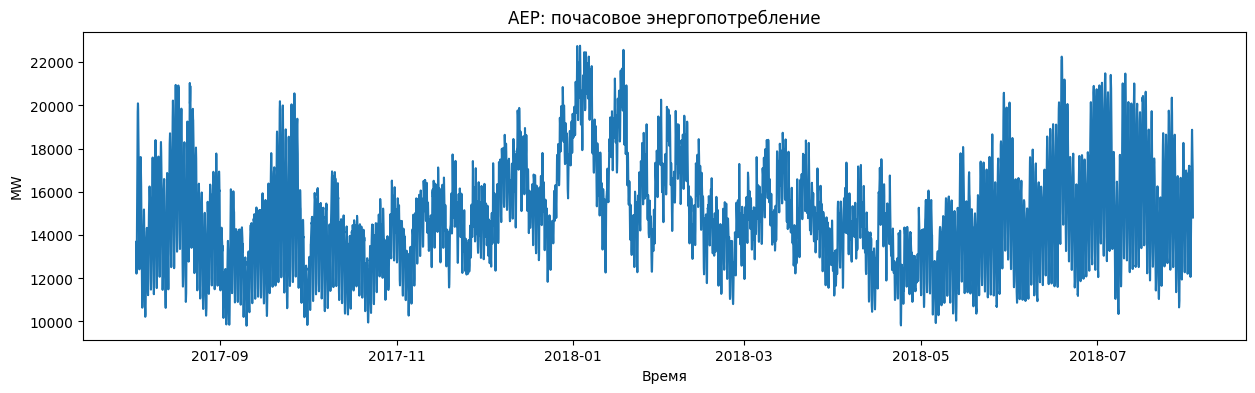

In [21]:

display(df["y"].describe().to_frame("AEP_MW"))
plt.figure(figsize=(15,4))
plt.plot(df["ds"], df["y"])
plt.title("AEP: почасовое энергопотребление")
plt.xlabel("Время")
plt.ylabel("MW")
plt.show()


### Суточная и недельная сезонность

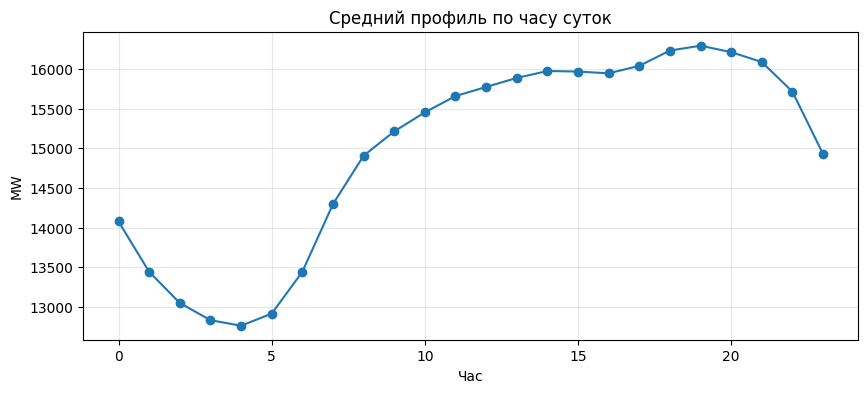

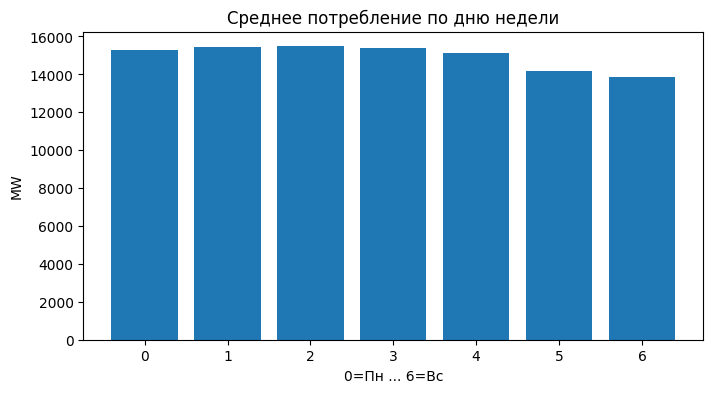

In [22]:

tmp = df.copy()
tmp["hour"] = tmp["ds"].dt.hour
tmp["dow"] = tmp["ds"].dt.dayofweek

hour_profile = tmp.groupby("hour")["y"].mean()
dow_profile = tmp.groupby("dow")["y"].mean()

plt.figure(figsize=(10,4))
plt.plot(hour_profile.index, hour_profile.values, marker="o")
plt.title("Средний профиль по часу суток")
plt.xlabel("Час")
plt.ylabel("MW")
plt.grid(alpha=.3)
plt.show()

plt.figure(figsize=(8,4))
plt.bar(dow_profile.index, dow_profile.values)
plt.title("Среднее потребление по дню недели")
plt.xlabel("0=Пн ... 6=Вс")
plt.ylabel("MW")
plt.show()


### ACF, STL и стационарность

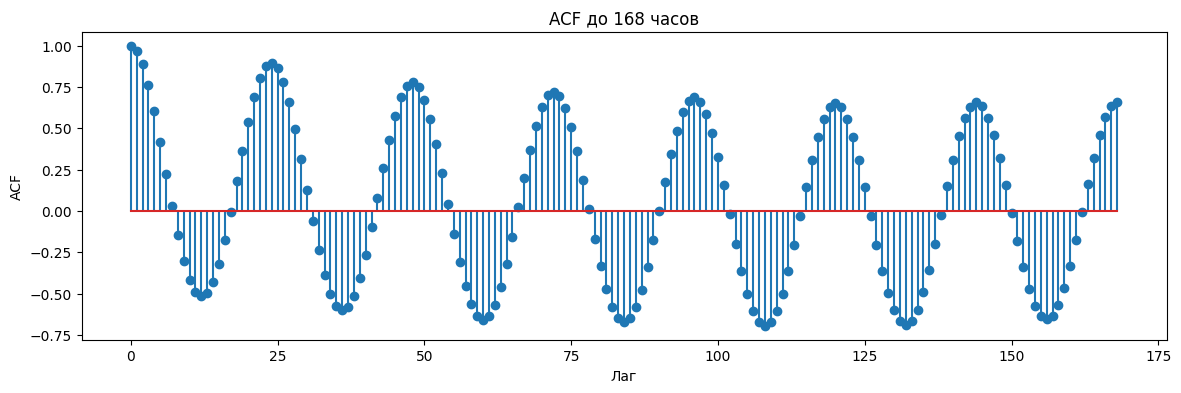

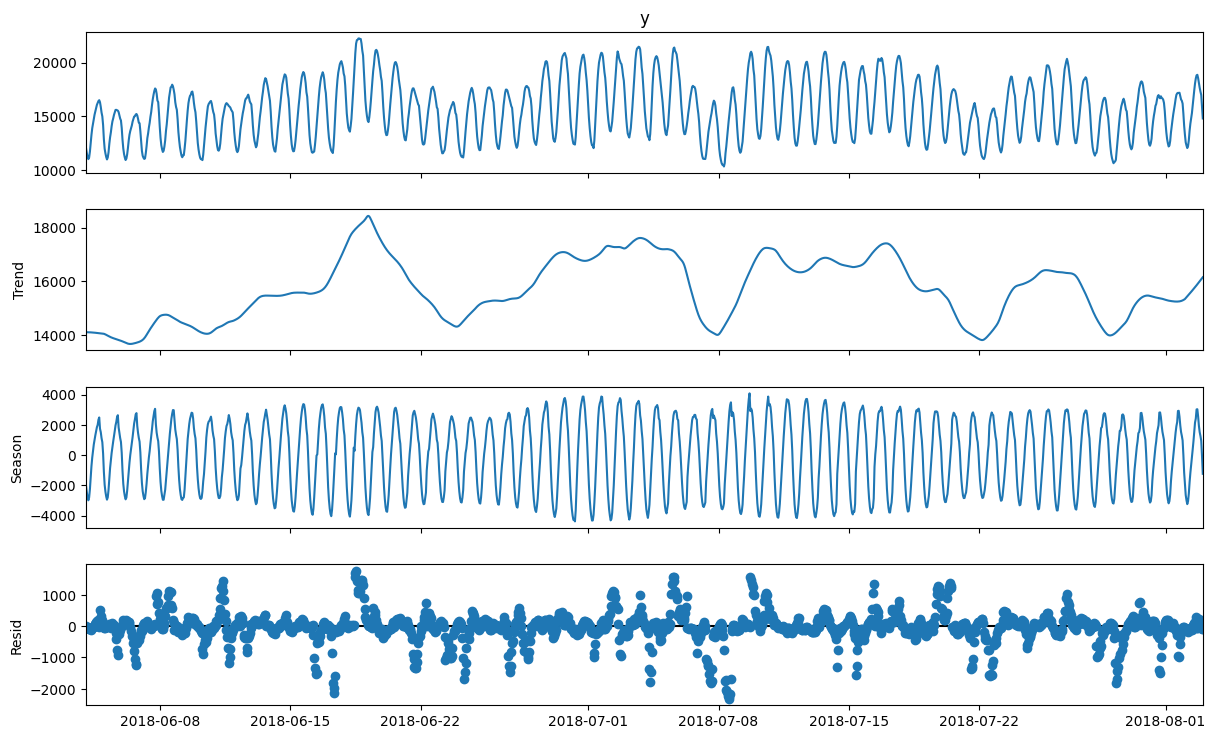

,n_obs,date_min,date_max,mean_MW,std_MW,min_MW,max_MW,missing_before_fill,ADF_level_pvalue,ADF_diff1_pvalue
0,8760,2017-08-03 01:00:00,2018-08-03,14963.490811,2438.436801,9801.0,22759.0,27,3.107167e-10,8.043983e-29


In [23]:

# Для скорости ACF и STL берём ограниченный фрагмент
sample = df["y"].tail(24*60).values
acf_vals = acf(sample, nlags=24*7, fft=True)

plt.figure(figsize=(14,4))
plt.stem(range(len(acf_vals)), acf_vals)
plt.title("ACF до 168 часов")
plt.xlabel("Лаг")
plt.ylabel("ACF")
plt.show()

stl_df = df.set_index("ds")["y"].tail(24*60)
stl = STL(stl_df, period=24, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(14,8)
plt.show()

adf_level = adfuller(df["y"].tail(min(len(df), 24*365)), autolag="AIC")
adf_diff = adfuller(df["y"].diff().dropna().tail(min(len(df)-1, 24*365)), autolag="AIC")

eda_summary = pd.DataFrame([{
    "n_obs": len(df),
    "date_min": df.ds.min(),
    "date_max": df.ds.max(),
    "mean_MW": df.y.mean(),
    "std_MW": df.y.std(),
    "min_MW": df.y.min(),
    "max_MW": df.y.max(),
    "missing_before_fill": missing_before,
    "ADF_level_pvalue": adf_level[1],
    "ADF_diff1_pvalue": adf_diff[1],
}])
eda_summary.to_csv("results/eda_summary.csv", index=False)
display(eda_summary)



### Вывод по задаче №1

Ряд является часовым и демонстрирует выраженную внутрисуточную и недельную структуру. Поэтому в дальнейшем используются `season_length=24`, недельный лаг `168`, а для MSTL — две сезонности `[24, 168]`. Результаты ADF позволяют отдельно оценить стационарность уровня и первой разности.



# Задача №2 — StatsForecast

Сравниваем SeasonalNaive и шесть статистических моделей. Это перекрывает требование ≥5 статистических методов.


In [24]:
from statsforecast import StatsForecast
from statsforecast.models import (
    Naive,
    SeasonalNaive,
    HistoricAverage,
    ARIMA,
    AutoETS,
    AutoTheta,
    HoltWinters,
)

# Делим данные на train и test
train = df.iloc[:-H].copy()
test = df.iloc[-H:].copy()

# Быстрый набор статистических моделей
models = [
    # Baseline
    Naive(),

    # Сезонный baseline
    SeasonalNaive(season_length=24),

    # Среднее исторических значений
    HistoricAverage(),

    # ARIMA с вручную заданными параметрами
    ARIMA(
        order=(2, 1, 2)
    ),

    # Автоматический ETS
    AutoETS(
        season_length=24
    ),

    # Theta
    AutoTheta(
        season_length=24
    ),

    # Holt-Winters
    HoltWinters(
        season_length=24
    ),
]

# Создаем объект StatsForecast
sf = StatsForecast(
    models=models,
    freq="h",
    n_jobs=-1
)

# Засекаем время
t0 = time.perf_counter()

# Прогноз
stat_fcst = sf.forecast(
    df=train,
    h=H,
    level=[80, 95]
)

stat_runtime = time.perf_counter() - t0

# Результат
display(stat_fcst.head())

print(
    "Runtime, sec:",
    round(stat_runtime, 2)
)

,unique_id,ds,Naive,Naive-lo-80,Naive-lo-95,Naive-hi-80,Naive-hi-95,SeasonalNaive,SeasonalNaive-lo-80,SeasonalNaive-lo-95,...,AutoTheta,AutoTheta-lo-80,AutoTheta-hi-80,AutoTheta-lo-95,AutoTheta-hi-95,HoltWinters,HoltWinters-lo-95,HoltWinters-lo-80,HoltWinters-hi-80,HoltWinters-hi-95
0,AEP,2018-08-02 01:00:00,14125.0,13459.548966,13107.280468,14790.451034,15142.719532,13538.0,11980.739594,11156.375731,...,13486.101418,13096.460644,13888.737225,12891.329102,14016.899936,13212.065411,11882.907948,12342.976060,14081.154763,14541.222875
1,AEP,2018-08-02 02:00:00,14125.0,13183.910123,12685.727235,15066.089877,15564.272765,12903.0,11345.739594,10521.375731,...,13089.725993,12611.028944,13593.170068,12345.899764,13785.940300,12541.021086,11204.417638,11667.063067,13414.979105,13877.624534
2,AEP,2018-08-02 03:00:00,14125.0,12972.404999,12362.258062,15277.595001,15887.741938,12506.0,10948.739594,10124.375731,...,12870.729139,12218.629673,13517.786961,11779.627799,13768.670400,12121.446401,10777.417425,11242.633090,13000.259712,13465.475378
3,AEP,2018-08-02 04:00:00,14125.0,12794.097932,12089.560935,15455.902068,16160.439065,12206.0,10648.739594,9824.375731,...,12799.953095,11990.994359,13553.462565,11636.356336,13785.246264,11872.966935,10521.532521,10989.311468,12756.622402,13224.401349
4,AEP,2018-08-02 05:00:00,14125.0,12637.006252,11849.309943,15612.993748,16400.690057,12295.0,10737.739594,9913.375731,...,12952.727916,12030.388866,13769.530891,11679.743419,14182.151603,11908.739812,10549.919693,11020.255093,12797.224532,13267.559932


Runtime, sec: 64.5


In [25]:

# Определяем колонки точечных прогнозов
id_cols = {"unique_id","ds"}
interval_tokens = ("-lo-80","-hi-80","-lo-95","-hi-95")
point_cols = [
    c for c in stat_fcst.columns
    if c not in id_cols and not any(tok in c for tok in interval_tokens)
]

stat_rows = []
for model in point_cols:
    m = calc_metrics(test["y"], stat_fcst[model])
    m["model"] = model
    m["family"] = "Stat/Baseline"
    stat_rows.append(m)

stat_metrics = pd.DataFrame(stat_rows).sort_values("MAE")
stat_metrics.to_csv("results/statistical_metrics.csv", index=False)
display(stat_metrics)


,MAE,RMSE,MAPE,sMAPE,model,family
1,660.458333,838.563926,3.856935,3.964646,SeasonalNaive,Stat/Baseline
6,790.338755,893.437625,4.778022,4.919448,HoltWinters,Stat/Baseline
5,1146.936983,1391.452733,6.884067,7.132177,AutoTheta,Stat/Baseline
3,1365.777713,1813.550561,7.829157,8.368494,ARIMA,Stat/Baseline
2,2150.679497,2432.954246,13.640593,13.892338,HistoricAverage,Stat/Baseline
4,2422.869413,2807.325926,14.709668,15.748524,AutoETS,Stat/Baseline
0,2422.916667,2807.390203,14.709884,15.748854,Naive,Stat/Baseline


### Визуализация статистических прогнозов

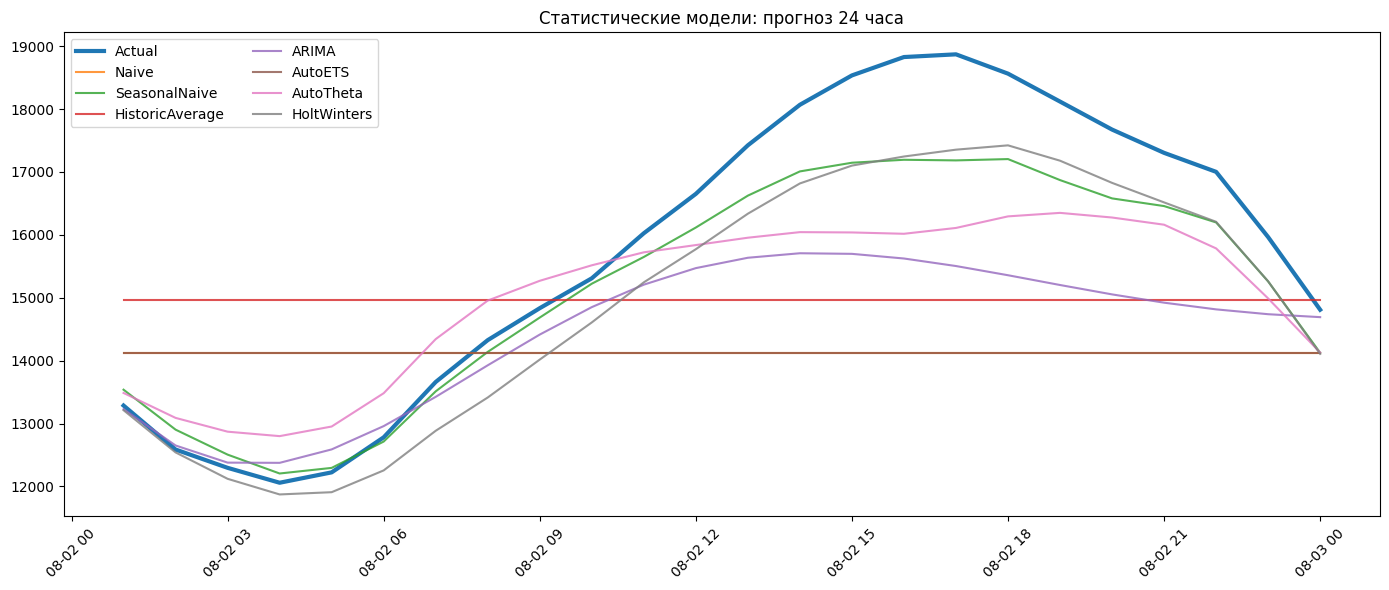

In [26]:

plot_df = test[["ds","y"]].merge(stat_fcst, on="ds", how="left")
plt.figure(figsize=(14,6))
plt.plot(plot_df["ds"], plot_df["y"], label="Actual", linewidth=3)
for c in point_cols:
    plt.plot(plot_df["ds"], plot_df[c], label=c, alpha=.8)
plt.title("Статистические модели: прогноз 24 часа")
plt.xticks(rotation=45)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


### Rolling backtesting

In [27]:

cv = sf.cross_validation(
    df=df,
    h=H,
    step_size=H,
    n_windows=N_WINDOWS,
    level=[80,95]
)

cv_point_cols = [
    c for c in cv.columns
    if c not in {"unique_id","ds","cutoff","y"}
    and not any(tok in c for tok in interval_tokens)
]

cv_rows = []
for cutoff, grp in cv.groupby("cutoff"):
    for model in cv_point_cols:
        m = calc_metrics(grp["y"], grp[model])
        m.update({"cutoff": cutoff, "model": model})
        cv_rows.append(m)
cv_metrics = pd.DataFrame(cv_rows)
display(cv_metrics.groupby("model")[["MAE","RMSE","MAPE","sMAPE"]].agg(["mean","std"]).round(2))


MAE             RMSE           MAPE        sMAPE      
                    mean     std     mean     std   mean   std   mean   std
model                                                                      
ARIMA            1200.67  385.34  1502.34  513.50   7.57  2.34   7.85  2.50
AutoETS          2057.00  361.56  2320.92  469.31  13.34  2.08  13.96  2.40
AutoTheta         879.02  379.25  1054.56  457.41   5.86  2.59   5.89  2.58
HistoricAverage  1870.98  297.30  2124.32  392.59  13.05  2.76  12.66  2.20
HoltWinters       776.67  491.88   866.93  467.03   5.15  3.23   5.30  3.51
Naive            2057.04  361.56  2320.97  469.31  13.34  2.08  13.96  2.40
SeasonalNaive     744.62  567.08   851.13  592.04   4.93  3.70   5.08  4.04

### Проверка покрытия вероятностных интервалов

In [28]:

coverage_rows = []
for model in cv_point_cols:
    lo80, hi80 = f"{model}-lo-80", f"{model}-hi-80"
    lo95, hi95 = f"{model}-lo-95", f"{model}-hi-95"
    row = {"model":model}
    if lo80 in cv and hi80 in cv:
        row["coverage_80"] = ((cv.y >= cv[lo80]) & (cv.y <= cv[hi80])).mean()
    if lo95 in cv and hi95 in cv:
        row["coverage_95"] = ((cv.y >= cv[lo95]) & (cv.y <= cv[hi95])).mean()
    coverage_rows.append(row)
coverage = pd.DataFrame(coverage_rows)
display(coverage)


,model,coverage_80,coverage_95
0,Naive,0.491667,0.808333
1,SeasonalNaive,0.875000,0.958333
2,HistoricAverage,0.866667,1.000000
3,ARIMA,0.858333,1.000000
4,AutoETS,0.491667,0.808333
5,AutoTheta,0.775000,0.908333
6,HoltWinters,0.675000,0.841667



### Вывод по задаче №2

Финальный выбор статистической модели делается по среднему MAE на rolling backtesting, а не только по одному тестовому окну. Дополнительно проверяются разброс MAE между окнами и покрытие 80/95% интервалов.



# Задача №3 — MLForecast

Feature engineering:
- лаги 1, 2, 24, 48, 168;
- rolling mean 24 и 168;
- календарные признаки.


In [29]:

from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

ml_models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=250 if not FAST_MODE else 100,
        max_depth=14,
        random_state=42,
        n_jobs=-1
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=500 if not FAST_MODE else 200,
        learning_rate=0.04,
        num_leaves=31,
        random_state=42,
        verbosity=-1
    ),
}

mlf = MLForecast(
    models=ml_models,
    freq="h",
    lags=[1,2,24,48,168],
    lag_transforms={
        1: [RollingMean(window_size=24)],
        24: [RollingMean(window_size=168)],
    },
    date_features=["hour","dayofweek","day","month"],
)

t0 = time.perf_counter()
mlf.fit(train)
ml_fcst = mlf.predict(H)
ml_runtime = time.perf_counter()-t0
display(ml_fcst.head())
print("Runtime, sec:", round(ml_runtime,2))


,unique_id,ds,LinearRegression,RandomForest,LightGBM
0,AEP,2018-08-02 01:00:00,13248.524726,13163.259873,13090.561454
1,AEP,2018-08-02 02:00:00,12653.995547,12499.184841,12431.797239
2,AEP,2018-08-02 03:00:00,12341.471887,12079.529651,12077.752743
3,AEP,2018-08-02 04:00:00,12291.477168,11898.523473,11802.199279
4,AEP,2018-08-02 05:00:00,12471.402505,11977.697267,11866.495197


Runtime, sec: 8.34


,MAE,RMSE,MAPE,sMAPE,model,family
2,548.445692,641.439422,3.315097,3.386206,LightGBM,ML
0,733.683411,992.794580,4.222914,4.378408,LinearRegression,ML
1,1241.272683,1580.505515,7.223142,7.646628,RandomForest,ML


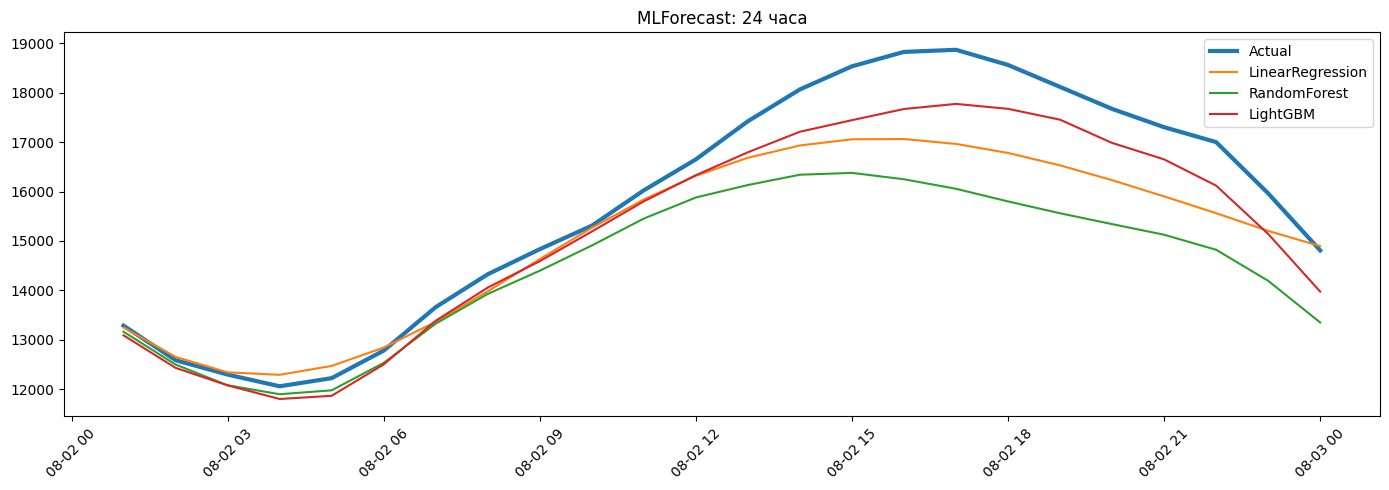

In [30]:

ml_rows = []
for model in ml_models:
    m = calc_metrics(test["y"], ml_fcst[model])
    m.update({"model":model, "family":"ML"})
    ml_rows.append(m)
ml_metrics = pd.DataFrame(ml_rows).sort_values("MAE")
ml_metrics.to_csv("results/ml_metrics.csv", index=False)
display(ml_metrics)

ml_plot = test[["ds","y"]].merge(ml_fcst, on="ds")
plt.figure(figsize=(14,5))
plt.plot(ml_plot.ds, ml_plot.y, label="Actual", linewidth=3)
for c in ml_models:
    plt.plot(ml_plot.ds, ml_plot[c], label=c)
plt.title("MLForecast: 24 часа")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()



# NeuralForecast — 3 DL-модели

Чтобы runtime в Colab оставался разумным, в `FAST_MODE` количество обучающих шагов уменьшено. Для финальной версии можно выставить `FAST_MODE=False`.


In [31]:

from neuralforecast import NeuralForecast
from neuralforecast.models import MLP, LSTM, NHITS

steps = 50 if FAST_MODE else 200
input_size = 168

dl_models = [
    MLP(h=H, input_size=input_size, max_steps=steps, random_seed=42),
    LSTM(h=H, input_size=input_size, max_steps=steps, random_seed=42),
    NHITS(h=H, input_size=input_size, max_steps=steps, random_seed=42),
]

nf = NeuralForecast(models=dl_models, freq="h")

t0 = time.perf_counter()
nf.fit(df=train)
dl_fcst = nf.predict()
dl_runtime = time.perf_counter()-t0
display(dl_fcst.head())
print("Runtime, sec:", round(dl_runtime,2))


INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | mlp                 | ModuleList    | 1.2 M  | train
7 | out                 | Linear        | 24.6 K | train
-----------------------------------------------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=50` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | hist_encoder        | LSTM          | 199 K  | train
7 | mlp_decoder         | MLP           | 16.6 K | train
--------------------------------------------------------------
215 K     Trainable params
0         Non-trainable params
215 

...

Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

,unique_id,ds,MLP,LSTM,NHITS
0,AEP,2018-08-02 01:00:00,13609.578125,13512.657227,13236.125977
1,AEP,2018-08-02 02:00:00,12786.011719,12742.900391,12433.741211
2,AEP,2018-08-02 03:00:00,13076.546875,12368.491211,12146.940430
3,AEP,2018-08-02 04:00:00,12794.322266,12248.537109,11962.874023
4,AEP,2018-08-02 05:00:00,13030.627930,12384.347656,11999.799805


Runtime, sec: 84.61


,MAE,RMSE,MAPE,sMAPE,model,family
2,600.158569,674.511309,3.695777,3.781744,NHITS,DL
1,685.857503,905.062474,3.958760,4.083486,LSTM,DL
0,1016.824829,1178.980243,6.159986,6.353738,MLP,DL


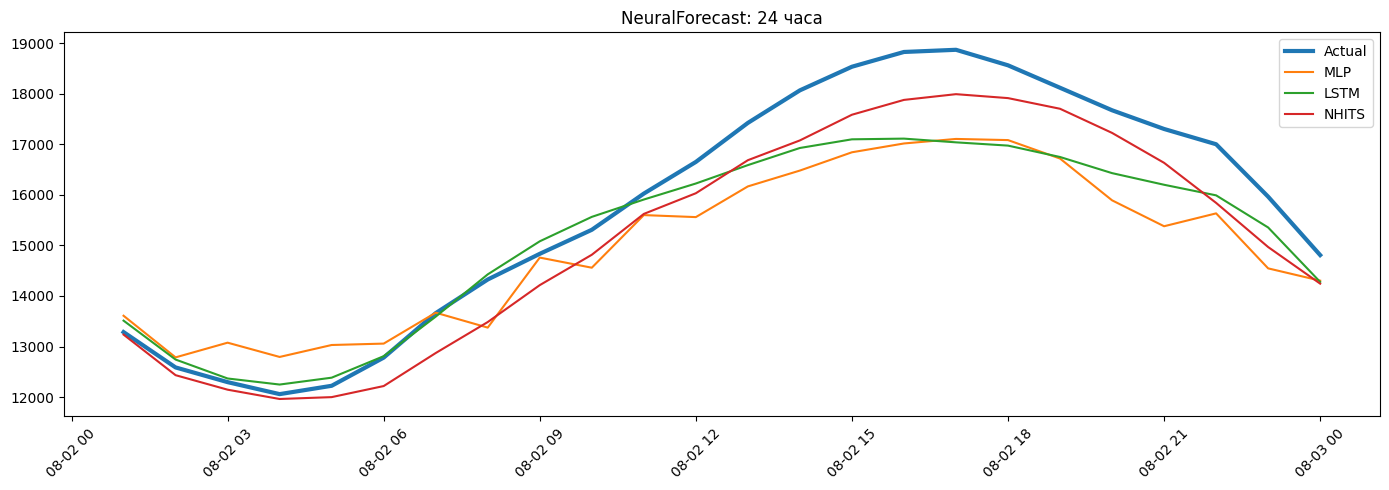

In [32]:

dl_names = [c for c in dl_fcst.columns if c not in ["unique_id","ds"]]
dl_rows = []
for model in dl_names:
    m = calc_metrics(test["y"], dl_fcst[model])
    m.update({"model":model, "family":"DL"})
    dl_rows.append(m)
dl_metrics = pd.DataFrame(dl_rows).sort_values("MAE")
dl_metrics.to_csv("results/dl_metrics.csv", index=False)
display(dl_metrics)

dl_plot = test[["ds","y"]].merge(dl_fcst, on="ds")
plt.figure(figsize=(14,5))
plt.plot(dl_plot.ds, dl_plot.y, label="Actual", linewidth=3)
for c in dl_names:
    plt.plot(dl_plot.ds, dl_plot[c], label=c)
plt.title("NeuralForecast: 24 часа")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()



### Вывод по задаче №3

ML и DL сравниваются на том же test horizon и с теми же метриками, что делает результаты сопоставимыми. Для ML используются осмысленные lag/date features, а DL получает 168 часов истории.


# Задача №4 — единое сравнение и выбор pipeline

In [33]:

all_metrics = pd.concat([stat_metrics, ml_metrics, dl_metrics], ignore_index=True)
all_metrics = all_metrics.sort_values("MAE").reset_index(drop=True)
all_metrics.to_csv("results/all_models_metrics.csv", index=False)

display(all_metrics.style.format({
    "MAE":"{:.2f}",
    "RMSE":"{:.2f}",
    "MAPE":"{:.2f}",
    "sMAPE":"{:.2f}",
}))

winner = all_metrics.iloc[0]
print(
    f"Лучшая модель на финальном hold-out: {winner['model']} | "
    f"MAE={winner['MAE']:.2f} MW | RMSE={winner['RMSE']:.2f} MW | "
    f"sMAPE={winner['sMAPE']:.2f}%"
)


,MAE,RMSE,MAPE,sMAPE,model,family
0,548.45,641.44,3.32,3.39,LightGBM,ML
1,600.16,674.51,3.70,3.78,NHITS,DL
2,660.46,838.56,3.86,3.96,SeasonalNaive,Stat/Baseline
3,685.86,905.06,3.96,4.08,LSTM,DL
4,733.68,992.79,4.22,4.38,LinearRegression,ML
5,790.34,893.44,4.78,4.92,HoltWinters,Stat/Baseline
6,1016.82,1178.98,6.16,6.35,MLP,DL
7,1146.94,1391.45,6.88,7.13,AutoTheta,Stat/Baseline
8,1241.27,1580.51,7.22,7.65,RandomForest,ML
9,1365.78,1813.55,7.83,8.37,ARIMA,Stat/Baseline


Лучшая модель на финальном hold-out: LightGBM | MAE=548.45 MW | RMSE=641.44 MW | sMAPE=3.39%



## Тест производительности

Измеряется wall-clock время основных блоков. Для корректного сравнения DL стоит запускать на одинаковом типе hardware (CPU/GPU).


In [34]:

performance = pd.DataFrame([
    {"block":"StatsForecast fit+forecast", "seconds":stat_runtime},
    {"block":"MLForecast fit+forecast", "seconds":ml_runtime},
    {"block":"NeuralForecast fit+forecast", "seconds":dl_runtime},
])
display(performance)


,block,seconds
0,StatsForecast fit+forecast,64.503029
1,MLForecast fit+forecast,8.344205
2,NeuralForecast fit+forecast,84.614370
